# Imports

In [450]:
import drjit as dr
import mitsuba as mi
import matplotlib.pyplot as plt
import numpy as np

# Configuration

In [451]:
# Select the variant to use
# Print out to view which you have available
# Need to pick an AD variant for gradient descent
# LLVM for CPU, CUDA for GPU
# Each requires its own installations
# print(mi.variants())
# mi.set_variant("llvm_ad_rgb")
mi.set_variant("cuda_ad_rgb")

# Configuration variables for the simulation
L = 10
f = 1
aperture = 10
half_aperture = aperture / 2
num_mirror1_segments = 50
num_2d_vertices = num_mirror1_segments + 1
three_dimensional_thickness = 0.5
target_height = 1
target_half_height = target_height / 2
optimization_iterations = 10000
optimization_rays = 1000
optimization_ray_max_y = half_aperture
optimization_ray_min_y = -half_aperture
learning_rate = 0.005
smoothing_loss_weight = 1.0
epsilon = 1e-6

# Target Mesh

In [452]:
# Set up the vertices to make up the flat target
target_vertices = mi.Point3f(
    [0, 0, 0, 0],
    [target_half_height, target_half_height, -target_half_height, -target_half_height],
    [three_dimensional_thickness, -three_dimensional_thickness, three_dimensional_thickness, -three_dimensional_thickness]
)

# Define the order of vertices for the faces
# One rectangle, so 2 triangles (the columns)
target_faces = mi.Vector3u(
    [0, 3],
    [1, 2],
    [2, 1]
)

# Create a mesh for the target to be able to be added to the scene
target_mesh = mi.Mesh(
    "target",
    vertex_count=4,
    face_count=2,
    has_vertex_normals=False,
    has_vertex_texcoords=False
)

# Add the vertices and faces to the mesh
target_mesh_params = mi.traverse(target_mesh)
target_mesh_params["vertex_positions"] = dr.ravel(target_vertices)
target_mesh_params["faces"] = dr.ravel(target_faces)

# Apply the mesh changes and print info to confirm correct creation
print(target_mesh_params.update())

[(Mesh[
  name = "target",
  bbox = BoundingBox3f[
    min = [0, -0.5, -0.5],
    max = [0, 0.5, 0.5]
  ],
  vertex_count = 4,
  vertices = [48 B of vertex data],
  face_count = 2,
  faces = [24 B of face data],
  face_normals = 0
], {'faces', 'vertex_positions'})]


# Mirror 1 Mesh

In [453]:
# Determine the vertices for the mirror's starting configuration which will just be a flat plane
# Since we're in 3D, have 2 points per y, which is the reason for the doubling
mirror1_y_points = dr.linspace(mi.Float, -half_aperture, half_aperture, num_2d_vertices)
mirror1_y_points = dr.repeat(mirror1_y_points, 2)
mirror1_x_points = dr.full(mi.Float, -L, len(mirror1_y_points))
mirror1_z_points = dr.tile(mi.Float(-three_dimensional_thickness, three_dimensional_thickness), num_2d_vertices)
mirror1_vertices = mi.Point3f(mirror1_x_points, mirror1_y_points, mirror1_z_points)

# Loop through and create 2 triangles per segment
mirror1_face_indices = []
for i in range(num_mirror1_segments):
    i0 = 2 * i                  # lower-left
    i1 = 2 * i + 1              # lower-right
    i2 = 2 * (i + 1)            # upper-left
    i3 = 2 * (i + 1) + 1        # upper-right

    mirror1_face_indices.append([i0, i2, i1])
    mirror1_face_indices.append([i1, i2, i3])

# Flatten out the faces, then reshape them into the expected mitsuba shape
faces_flat = [index for tri in mirror1_face_indices for index in tri]
mirror1_faces = dr.reshape(mi.Vector3u, mi.UInt32(faces_flat), (-1, 3))

# Create the mirror mesh
mirror1_mesh = mi.Mesh(
    "mirror1",
    vertex_count=len(mirror1_y_points),
    face_count=num_mirror1_segments * 2,
    has_vertex_normals=True,
    has_vertex_texcoords=False,
)

# Add the vertices and faces to the mesh
mirror1_mesh_params = mi.traverse(mirror1_mesh)
mirror1_mesh_params["vertex_positions"] = dr.ravel(mirror1_vertices)
mirror1_mesh_params["faces"] = dr.ravel(mirror1_faces)

# Apply the mesh changes and print info to confirm correct creation
print(mirror1_mesh_params.update())

[(Mesh[
  name = "mirror1",
  bbox = BoundingBox3f[
    min = [-10, -5, -0.5],
    max = [-10, 5, 0.5]
  ],
  vertex_count = 102,
  vertices = [2.39 KiB of vertex data],
  face_count = 100,
  faces = [1.17 KiB of face data],
  face_normals = 0
], {'faces', 'vertex_positions'})]


# Cameras

In [454]:
# Create a camera to look at the target
target_camera = mi.load_dict({
    "type": "orthographic",
    "to_world": mi.ScalarTransform4f().look_at(
        origin=[-1, 0, 0], target=[0, 0, 0], up=[0, 1, 0]
    ) @ mi.ScalarAffineTransform4f().scale([1, 1, 1])
})

# Create a camera to look at the whole scene
scene_camera = mi.load_dict({
    "type": "perspective",
    "to_world": mi.ScalarTransform4f().look_at(
        origin=[0, 0, aperture * 2], target=[-L, 0, 0], up=[0, 1, 0]
    ),
})

# Full Scene

In [455]:
# Create the scene
# For the single mirror case, only the mirror is really required
# The light, integrator, and target aren't really used unless you want to render with mitsuba, but left for informational purposes
scene = mi.load_dict({
    "type": "scene",
    "integrator": {"type": "path"},
    "light": {
        "type": "directional",
        "direction": [-1, 0, 0]
    },
    "target": target_mesh,
    "mirror1": mirror1_mesh
})

# Scene Parameters

In [456]:
# Get the scene information
scene_params = mi.traverse(scene)

# Display the scene information
# Not used here as we write custom tracing for a custom loss function, but this is where we can see which parameters we can optimize and are differentiable
print(scene_params)

SceneParameters[
  -----------------------------------------------------------------------------------------
  Name                                  Flags    Type              Parent
  -----------------------------------------------------------------------------------------
  allow_thread_reordering                        bool              Scene
  target.bsdf.reflectance.value         ∂        Float             UniformSpectrum
  target.silhouette_sampling_weight              float             Mesh
  target.faces                                   UInt              Mesh
  target.vertex_positions               ∂, D     Float             Mesh
  target.vertex_normals                 ∂, D     Float             Mesh
  target.vertex_texcoords               ∂        Float             Mesh
  mirror1.bsdf.reflectance.value        ∂        Float             UniformSpectrum
  mirror1.silhouette_sampling_weight             float             Mesh
  mirror1.faces                                  UInt 

# Optimization

In [457]:
# Prepare the optimization
target_center = mi.Vector3f(0, 0, 0)
opt = mi.ad.Adam(lr=learning_rate)
opt['mirror_1_xy_offsets'] = dr.zeros(mi.Vector2f, num_2d_vertices)

# Prepare the constraints
# We freeze the x,y of the middle vertex, and also freeze the y of the top-most and bottom-most vertices
mask_x = dr.ones(mi.Float, num_2d_vertices)
mask_y = dr.ones(mi.Float, num_2d_vertices)
dr.scatter(mask_x, 0.0, mi.UInt32([num_2d_vertices // 2]))
dr.scatter(mask_y, 0.0, mi.UInt32([0, num_2d_vertices // 2, num_2d_vertices - 1]))

def update_scene():
    """
    Apply the computed offsets to the vertices
    """
    # Copy the offsets and dupe them to allow for two per line segment due to being in 3D
    current_offsets = opt['mirror_1_xy_offsets']
    repeated_current_offsets = dr.repeat(current_offsets, 2)

    # Add the offsets to the x and y
    # Z is not modified so leave it be
    new_x = mirror1_vertices.x + repeated_current_offsets.x
    new_y = mirror1_vertices.y + repeated_current_offsets.y
    new_z = mirror1_vertices.z

    # Reshape and modify the scene
    scene_params['mirror1.vertex_positions'] = dr.ravel(mi.Point3f(new_x, new_y, new_z))

    # Propagate changes through the scene (e.g. rebuild BVH)
    scene_params.update()

# The main optimization loop
for i in range(optimization_iterations):
    # Generate rays to use for the computation of loss
    # Rays are linearly-spaced across a broad area which will more than cover the first mirror
    # Max is not differentiable, so we just overshoot to avoid DrJIT issues
    ray_ys = dr.linspace(mi.Float, optimization_ray_min_y, optimization_ray_max_y, optimization_rays)
    ray_dir = mi.Vector3f(-1, 0, 0)
    ray_origins = mi.Point3f(-1.0, ray_ys, 0.0)
    rays = mi.Ray3f(o=ray_origins, d=ray_dir)

    # Intersect with the mirror
    si = scene.ray_intersect(rays)
    hit_mask = si.is_valid()

    # Perform a perfect, specular reflection
    # $wo$ is the reflected direction: $wo = wi - 2 * (wi \cdot n) * n$
    wo = rays.d - 2 * dr.dot(rays.d, si.n) * si.n
    reflected_rays = si.spawn_ray(wo)

    # Since the target may not be big enough, intersect with the plane upon which it resides
    # $p = o + t * d$
    # We only care about $x=0$
    # $0 = o.x + t * d.x$
    # $t = -o.x / d.x$
    # The selection is to avoid division by zero, in the event where we're parallel
    # Also, not caring to do a dot product since it's at the origin so it just becomes the same; would need it if the target is moved
    denom = dr.select(dr.abs(reflected_rays.d.x) > epsilon, reflected_rays.d.x, epsilon)
    t = -reflected_rays.o.x / denom

    # Just plug in the t to figure out where we hit
    hit_points = reflected_rays.o + t * reflected_rays.d

    # View the loss only as the difference in y position at the target plane
    # Using square instead of norm (square root) to avoid NaN issues at $y=0$
    # By using a hit mask, we only consider the rays which actually hit the mirror, which removes error from those which missed (which would behave as though they hit the centre)
    # The original loss function which doesn't take this into account is left below for comparison
    # loss = dr.mean(dr.square(hit_points.y - target_center.y))
    square_distance = dr.square(hit_points.y - target_center.y)
    masked_square_distance = dr.select(hit_mask, square_distance, 0.0)
    hit_count = dr.count(hit_mask)
    loss = dr.sum(masked_square_distance) / dr.maximum(hit_count, 1.0)

    # To add some additional smoothness to avoid vertices moving too out of step with each other, try to add some additional loss to penalize it
    # We're basically treating it as a spline
    # This also makes sure that the values remain attached after the ray intersections
    # Get the offsets and compute the difference between adjacent vertices
    # Another, nicer option is to take the difference in slopes instead to penalize slope jumps instead of distance jumps (pick one from the provided options)
    # Square the differences for both x and y to get the smoothness penalty
    # Combine with the loss in position, weighted
    offsets = opt['mirror_1_xy_offsets']
    # Distance jump penalty
    # diff = offsets[1:] - offsets[:-1]
    # smoothness_penalty = dr.mean(dr.square(diff.x) + dr.square(diff.y))
    # Slope jump penalty
    lx = offsets.x[2:] - mi.Float(2.0) * offsets.x[1:-1] + offsets.x[:-2]
    ly = offsets.y[2:] - mi.Float(2.0) * offsets.y[1:-1] + offsets.y[:-2]
    smoothness_penalty = dr.mean(dr.square(lx) + dr.square(ly))
    loss += smoothing_loss_weight * smoothness_penalty

    # Perform the gradient descent
    dr.backward(loss)

    # Pin the middle point, as well as the y values of the top and bottom points
    grads = dr.grad(opt['mirror_1_xy_offsets'])
    grads.x *= mask_x
    grads.y *= mask_y
    dr.set_grad(opt['mirror_1_xy_offsets'], grads)

    # Take the step
    opt.step()

    # Get the latest scene version from the optimized values
    update_scene()

    # Log how we're doing in terms of loss
    print(f"Iteration {i + 1:06d}: loss={loss[0]:.4f}")

Iteration 000001: loss=8.3334
Iteration 000002: loss=8.3334
Iteration 000003: loss=8.0839
Iteration 000004: loss=7.7929
Iteration 000005: loss=7.5378
Iteration 000006: loss=7.2835
Iteration 000007: loss=7.0427
Iteration 000008: loss=6.8191
Iteration 000009: loss=6.5980
Iteration 000010: loss=6.3954
Iteration 000011: loss=6.2091
Iteration 000012: loss=6.0180
Iteration 000013: loss=5.8644
Iteration 000014: loss=5.7031
Iteration 000015: loss=5.5483
Iteration 000016: loss=5.4128
Iteration 000017: loss=5.2722
Iteration 000018: loss=5.1602
Iteration 000019: loss=5.0434
Iteration 000020: loss=4.9375
Iteration 000021: loss=4.8364
Iteration 000022: loss=4.7456
Iteration 000023: loss=4.6624
Iteration 000024: loss=4.5746
Iteration 000025: loss=4.5032
Iteration 000026: loss=4.4363
Iteration 000027: loss=4.3693
Iteration 000028: loss=4.3101
Iteration 000029: loss=4.2581
Iteration 000030: loss=4.2006
Iteration 000031: loss=4.1540
Iteration 000032: loss=4.1020
Iteration 000033: loss=4.0571
Iteration 

# Final Mirror

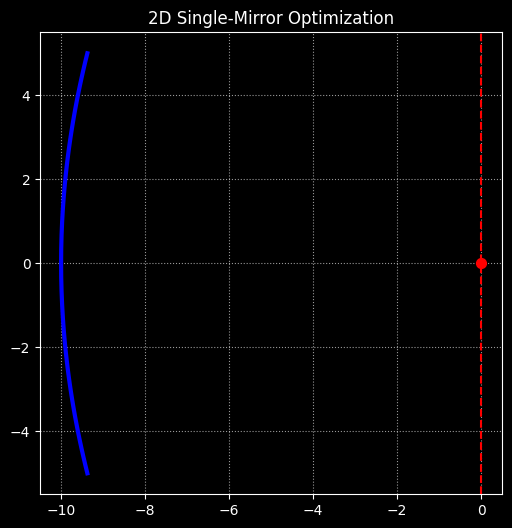

In [458]:
# Extract the optimized data
final_offsets = opt['mirror_1_xy_offsets']

# We only optimize the single set, but double it for the 3d
repeated_offsets = dr.repeat(final_offsets, 2)

# Get the actual values, where we only need half of them as we don't need both the points with the different z values
final_x = np.array(mirror1_vertices.x + repeated_offsets.x)[::2]
final_y = np.array(mirror1_vertices.y + repeated_offsets.y)[::2]

# Create the figure
plt.figure(figsize=(10, 6))

# Draw the mirror by connecting the vertices
# Sort by Y just in case they got buffeted out of order
sort_idx = np.argsort(final_y)
plt.plot(final_x[sort_idx], final_y[sort_idx], 'b-', lw=3, label='Optimized Mirror')

# Draw the target plane and centre
plt.axvline(x=0, color='red', linestyle='--', label='Target Plane (x=0)')
plt.scatter([0], [target_center.y], color='red', s=50, zorder=5, label='Target Centre')

# Labels and formatting
plt.title('2D Single-Mirror Optimization')
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')

# Display
plt.show()

# Final Scene

In [459]:
reference_scene_image = mi.render(scene, sensor=scene_camera, spp=100)
mi.util.convert_to_bitmap(reference_scene_image)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [768, 576],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 1.27 MiB of image data ]
]

# Final Target

In [460]:
# Make the mirror a true mirror
# This only matters if you want to render the scene with mitsuba, which isn't strictly necessary as we plot with matplotlib later, but leaving it in for interest
# The "true ideal" mirror is also provided, but given probabilities, is vanishingly unlikely to hit anything
ideal_mirror_bsdf = mi.load_dict({
    'type': 'conductor',
    'material': 'none'
})
mirror_bsdf = mi.load_dict({
    'type': 'roughconductor',
    "alpha": 0.005,
})
# mirror1_mesh.set_bsdf(ideal_mirror_bsdf)
mirror1_mesh.set_bsdf(mirror_bsdf)

reference_scene_image = mi.render(scene, sensor=target_camera, spp=1000)
mi.util.convert_to_bitmap(reference_scene_image)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [768, 576],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 1.27 MiB of image data ]
]